In [1]:
import pandas as pd
import polaris as po
import base64
import numpy as npz

In [2]:
from rdkit import Chem

In [3]:
submissions = pd.read_json("./latest_competition_prediction.json")


In [4]:
def determine_subchallenge(data):
    sub = data["test"]
    if "Ligand Pose" in sub.keys():
        challenge = "Ligand Pose"
    elif "pIC50 (MERS-CoV Mpro)" and "pIC50 (SARS-CoV-2 Mpro)" in sub.keys():
        challenge = "Potency"
    elif "HLM" and "MLM" in sub.keys():
        challenge = "ADMET"
    else:
        raise ValueError()
    return challenge
        

In [5]:
submissions["subchallenge"] = submissions["predictions"].apply(determine_subchallenge)
submissions["predictions_unnested"] = submissions["predictions"].apply(lambda x: x["test"])

# Poses

In [22]:
poses_dataset = po.load_dataset("asap-discovery/antiviral-ligand-poses-2025-unblinded")
poses_data = pd.DataFrame(poses_dataset[:])

[2025-11-03 17:32:27] INFO     The version of Polaris that was used to create the artifact          ]8;id=387383;file:///Users/jenkescheen/projects/polaris/polaris/polaris/_artifact.py\_artifact.py]8;;\:]8;id=11553;file:///Users/jenkescheen/projects/polaris/polaris/polaris/_artifact.py#92\92]8;;\
                               (0.11.8.dev4+g40e3b2b.d20250207) is different from the currently                    
                               installed version of Polaris (0.11.7).                                              

                      WARNING  You're loading data from a remote location. If the dataset is small     ]8;id=925013;file:///Users/jenkescheen/projects/polaris/polaris/polaris/dataset/_base.py\_base.py]8;;\:]8;id=119125;file:///Users/jenkescheen/projects/polaris/polaris/polaris/dataset/_base.py#182\182]8;;\
                               enough, consider caching the dataset first using DatasetV2.cache() for              
                               more performant data access.                                                        

[17:32:28]  Success: Fetching dataset                                                                 ]8;id=404260;file:///Users/jenkescheen/projects/polaris/polaris/polaris/utils/context.py\context.py]8;;\:]8;id=601340;file:///Users/jenkescheen/projects/polaris/polaris/polaris/utils/context.py#53\53]8;;\

In [23]:
poses_test = poses_data.query("Set == 'Test'")

In [24]:
poses_test.reset_index(drop=True, inplace=True)

In [25]:
y_true = poses_test["Ligand Pose"]

In [26]:
protein_labels = poses_test["Protein Label"]
protein_labels

0        MERS-CoV Mpro
1        MERS-CoV Mpro
2      SARS-CoV-2 Mpro
3        MERS-CoV Mpro
4        MERS-CoV Mpro
            ...       
190    SARS-CoV-2 Mpro
191    SARS-CoV-2 Mpro
192      MERS-CoV Mpro
193    SARS-CoV-2 Mpro
194    SARS-CoV-2 Mpro
Name: Protein Label, Length: 195, dtype: object

In [27]:
poses_submissions = submissions.query("subchallenge == 'Ligand Pose'")

In [28]:
for _, entry in poses_submissions.iterrows():
    print(entry["id"], entry["name"], "%%%", entry["description"], "%%%", entry["github_url"], "%%%", entry["report_url"], "\n")

competition-prediction-8oFF30AHg20eUKrnRQzUE asap-gnina-docking-baseline %%% Baseline docking for model comparison (both targets) %%% None %%% https://github.com/asapdiscovery/asap-polaris-challenge-baselines 

competition-prediction-Edd645cpFboFZRsUm20em protocol2 %%%  %%% None %%% https://docs.google.com/document/d/1QujhEKtMpdUwFxE_AVq6RBzsHEh4gjkd/edit?usp=sharing&ouid=102900202710669481806&rtpof=true&sd=true 

competition-prediction-tXLnHU72dFljtgWAuvh8Z openfe-newcastle-edinburgh-mcs-fegrow %%% FEGrow with mcs core structure finder. %%% https://github.com/jthorton/polaris_fegrow_mcs %%% https://github.com/jthorton/polaris_fegrow_mcs 

competition-prediction-late-im0HtqthslCqgR1BHgf9b asap-boltz-1-submission %%% Boltz aligned ligand poses %%% None %%% https://apricot-zorah-51.tiiny.site 

competition-prediction-sqr7BVpSxy4NSgljcEgl8 dodo-poses-submission %%% Submission generated using easydock pipeline with substructure alignment %%% https://github.com/fulopjoz/polaris-antiviral-su

In [29]:
entry_categories = {
    "competition-prediction-8oFF30AHg20eUKrnRQzUE": "PB",
    "competition-prediction-Edd645cpFboFZRsUm20em": "DL",
    "competition-prediction-tXLnHU72dFljtgWAuvh8Z": "PB",
    "competition-prediction-late-im0HtqthslCqgR1BHgf9b": "CF",
    "competition-prediction-sqr7BVpSxy4NSgljcEgl8": "PB",
    "competition-prediction-t4heZQ05hXlJ6vcfhZjP2": "PB",
    "competition-prediction-GL85gNve6u38L33Q2wUiJ": "DL",
    "competition-prediction-Kec3G0H9KJGWfRouaHDLQ": "PB",
    "competition-prediction-JPiM6etVV4SNygnvAZqj7": "CF",
    "competition-prediction-M0ePYflVVxiF79RnRcCkC": "PB",
    "competition-prediction-S9yhyrYVraSy6vZ3u0iwS": "DL",
    "competition-prediction-pxXgSbG31dfMbqohnMnfP": "CF",
    "competition-prediction-DLGeSzUxB29MqK9pnBawM": "PB",
    "competition-prediction-8ygjELYPeCo3or8AS6Xom": "DL",
    "competition-prediction-o8n3Fgdevuj8th3FfUNu1": "DL",
    "competition-prediction-TPDYWfhEw4nYp81Kd5s1W": "CF",
    "competition-prediction-th7lSmtpv1tMxmNjYqCJU": "PB",
    "competition-prediction-kMD7A97Q9b7wnRH8Ze9e": "PB",
    "competition-prediction-TSWQyQgwNyUbdp5EaGbmU": "PB",
    "competition-prediction-SXMdEmccFmbNBtiVCZvp9": "CF",
    "competition-prediction-JLy17Fu87yM2ch741quDp": "PB",
    "competition-prediction-MoEWcKkwYkPeFHrw3qaWd": "PB",
    "competition-prediction-sKvyY8FZzDDX1jaFpBG8t": "CF",
    "competition-prediction-GZRD1499Q0k3ejSX7wR22": "PB",
    'competition-prediction-kMD7A97Q9b7wnRH8Ze9e9': "PB",
}

In [30]:
BASELINE_ID = "competition-prediction-DLGeSzUxB29MqK9pnBawM"

In [31]:
poses_compact = poses_submissions[["id","predictions_unnested"]].set_index("id")

In [32]:
poses_compact

,predictions_unnested
id,
competition-prediction-8oFF30AHg20eUKrnRQzUE,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...
competition-prediction-Edd645cpFboFZRsUm20em,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...
competition-prediction-tXLnHU72dFljtgWAuvh8Z,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...
competition-prediction-late-im0HtqthslCqgR1BHgf9b,{'Ligand Pose': ['776t3gAAAAAQAAAAAQAAAAAAAAAp...
competition-prediction-sqr7BVpSxy4NSgljcEgl8,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...
competition-prediction-t4heZQ05hXlJ6vcfhZjP2,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAA/...
competition-prediction-GL85gNve6u38L33Q2wUiJ,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...
competition-prediction-Kec3G0H9KJGWfRouaHDLQ,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAA/...
competition-prediction-JPiM6etVV4SNygnvAZqj7,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...


In [33]:
def deserialize_rdkit_mol(b64_string: str) -> Chem.Mol:
    mol_bytes = base64.b64decode(b64_string)
    return Chem.Mol(mol_bytes)

In [34]:
def serialized_list_to_rdkit(data: list[str]) -> list[Chem.Mol]:
    mols = []
    for d in data:
        mols.append(deserialize_rdkit_mol(d))
    return mols

In [35]:
poses_compact["predictions_rdkit_mols"] = poses_compact["predictions_unnested"].apply(lambda x: serialized_list_to_rdkit(x["Ligand Pose"]))

In [36]:
poses_compact

,predictions_unnested,predictions_rdkit_mols
id,,
competition-prediction-8oFF30AHg20eUKrnRQzUE,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...,[<rdkit.Chem.rdchem.Mol object at 0x29ca7b240>...
competition-prediction-Edd645cpFboFZRsUm20em,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...,[<rdkit.Chem.rdchem.Mol object at 0x29cb74590>...
competition-prediction-tXLnHU72dFljtgWAuvh8Z,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...,[<rdkit.Chem.rdchem.Mol object at 0x29ccfb9c0>...
competition-prediction-late-im0HtqthslCqgR1BHgf9b,{'Ligand Pose': ['776t3gAAAAAQAAAAAQAAAAAAAAAp...,[<rdkit.Chem.rdchem.Mol object at 0x29cd21210>...
competition-prediction-sqr7BVpSxy4NSgljcEgl8,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...,[<rdkit.Chem.rdchem.Mol object at 0x29cc60770>...
competition-prediction-t4heZQ05hXlJ6vcfhZjP2,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAA/...,[<rdkit.Chem.rdchem.Mol object at 0x29cc83790>...
competition-prediction-GL85gNve6u38L33Q2wUiJ,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...,[<rdkit.Chem.rdchem.Mol object at 0x29cc9c2c0>...
competition-prediction-Kec3G0H9KJGWfRouaHDLQ,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAA/...,[<rdkit.Chem.rdchem.Mol object at 0x29cc23650>...
competition-prediction-JPiM6etVV4SNygnvAZqj7,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...,[<rdkit.Chem.rdchem.Mol object at 0x29ccaae30>...


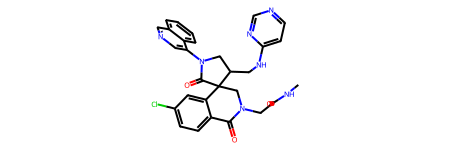

In [37]:
poses_compact["predictions_rdkit_mols"].iloc[0][2]

In [38]:
poses_compact_dict = poses_compact.to_dict()["predictions_rdkit_mols"]

In [39]:
poses_compact_dict

{'competition-prediction-8oFF30AHg20eUKrnRQzUE': [<rdkit.Chem.rdchem.Mol at 0x29ca7b240>,
 'competition-prediction-Edd645cpFboFZRsUm20em': [<rdkit.Chem.rdchem.Mol at 0x29cb74590>,
 'competition-prediction-tXLnHU72dFljtgWAuvh8Z': [<rdkit.Chem.rdchem.Mol at 0x29ccfb9c0>,
 'competition-prediction-late-im0HtqthslCqgR1BHgf9b': [<rdkit.Chem.rdchem.Mol at 0x29cd21210>,
 'competition-prediction-sqr7BVpSxy4NSgljcEgl8': [<rdkit.Chem.rdchem.Mol at 0x29cc60770>,
 'competition-prediction-t4heZQ05hXlJ6vcfhZjP2': [<rdkit.Chem.rdchem.Mol at 0x29cc83790>,
 'competition-prediction-GL85gNve6u38L33Q2wUiJ': [<rdkit.Chem.rdchem.Mol at 0x29cc9c2c0>,
 'competition-prediction-Kec3G0H9KJGWfRouaHDLQ': [<rdkit.Chem.rdchem.Mol at 0x29cc23650>,
 'competition-prediction-JPiM6etVV4SNygnvAZqj7': [<rdkit.Chem.rdchem.Mol at 0x29ccaae30>,
 'competition-prediction-M0ePYflVVxiF79RnRcCkC': [<rdkit.Chem.rdchem.Mol at 0x29ccf04a0>,
 'competition-prediction-S9yhyrYVraSy6vZ3u0iwS': [<rdkit.Chem.rdchem.Mol at 0x29cccb5b0>,
 'com

In [40]:
# combine the top entries into a single one using the best performing one as suggested by the group
to_exclude = ["competition-prediction-sKvyY8FZzDDX1jaFpBG8t", "competition-prediction-SXMdEmccFmbNBtiVCZvp9", "competition-prediction-Edd645cpFboFZRsUm20em"]

In [41]:
for label in to_exclude:
    del poses_compact_dict[label]

In [42]:
poses_compact_dict

{'competition-prediction-8oFF30AHg20eUKrnRQzUE': [<rdkit.Chem.rdchem.Mol at 0x29ca7b240>,
 'competition-prediction-tXLnHU72dFljtgWAuvh8Z': [<rdkit.Chem.rdchem.Mol at 0x29ccfb9c0>,
 'competition-prediction-late-im0HtqthslCqgR1BHgf9b': [<rdkit.Chem.rdchem.Mol at 0x29cd21210>,
 'competition-prediction-sqr7BVpSxy4NSgljcEgl8': [<rdkit.Chem.rdchem.Mol at 0x29cc60770>,
 'competition-prediction-t4heZQ05hXlJ6vcfhZjP2': [<rdkit.Chem.rdchem.Mol at 0x29cc83790>,
 'competition-prediction-GL85gNve6u38L33Q2wUiJ': [<rdkit.Chem.rdchem.Mol at 0x29cc9c2c0>,
 'competition-prediction-Kec3G0H9KJGWfRouaHDLQ': [<rdkit.Chem.rdchem.Mol at 0x29cc23650>,
 'competition-prediction-JPiM6etVV4SNygnvAZqj7': [<rdkit.Chem.rdchem.Mol at 0x29ccaae30>,
 'competition-prediction-M0ePYflVVxiF79RnRcCkC': [<rdkit.Chem.rdchem.Mol at 0x29ccf04a0>,
 'competition-prediction-S9yhyrYVraSy6vZ3u0iwS': [<rdkit.Chem.rdchem.Mol at 0x29cccb5b0>,
 'competition-prediction-pxXgSbG31dfMbqohnMnfP': [<rdkit.Chem.rdchem.Mol at 0x29cad3f10>,
 'com

In [43]:
# we know the problem pose for SARS-CoV-2 Mpro has the following O=C(Cc1cncc2ccccc12)N(Cc1cccc(Cl)c1)[C@]12C[N@@H+](C3CC3)[C@H](C1)C
# define the evaluation logic again taking into account that we need to remove this molecule from the evaluation
from evaluation.cld import add_cld_to_leaderboard
from evaluation.bootstrapping import bootstrapping_sampler
import spyrmsd.molecule
import spyrmsd.rmsd

def mol_has_3D(mol):
    try:
        mol.GetConformer()
    except ValueError:
        raise ValueError("Cannot get conformer for molecule, is likely 2D")

    if not mol.GetConformer().Is3D():
        raise ValueError("Molecule is not 3D")

def evaluate_ligand_poses_predictions(
    y_pred: list[Chem.Mol],
    y_true: list[Chem.Mol],
    method_label: str,
    inputs: pd.DataFrame,
    cutoff: float = 2.0,
    n_bootstrap_samples: int = 1000,
    series: str = "all"
):
    import json
    rmsds = []

    sars_bad_mol = "O=C(Cc1cncc2ccccc12)N(Cc1cccc(Cl)c1)[C@]12C[N@@H+](C3CC3)[C@H](C1)C2"

    if series not in ["all", "MERS-CoV Mpro", "SARS-CoV-2 Mpro"]:
        raise ValueError("Invalid series specified. Must be 'all', 'MERS-CoV Mpro', or 'SARS-CoV-2 Mpro'.")
    if series in ["all", "SARS-CoV-2 Mpro"]:
        if series == "SARS-CoV-2 Mpro":
            # Filter inputs for SARS-CoV-2 Mpro
            inputs = inputs[inputs["Protein Label"] == "SARS-CoV-2 Mpro"].copy(deep=True).reset_index(drop=True)
        # Get the index of the bad molecule
        bad_mol_index = inputs[inputs["CXSMILES"] == sars_bad_mol].index.values[0]
        print(f"Bad molecule index: {bad_mol_index}")
        # Remove the bad molecule from inputs
        inputs = inputs.drop(bad_mol_index).reset_index(drop=True)

        # Remove the bad molecule from y_true and y_pred
        y_true = [y_true[i] for i in range(len(y_true)) if i != bad_mol_index]
        y_pred = [y_pred[i] for i in range(len(y_pred)) if i != bad_mol_index]
    elif series == "MERS-CoV Mpro":
        # Filter inputs for MERS-CoV Mpro
        inputs = inputs[inputs["Protein Label"] == "MERS-CoV Mpro"].copy(deep=True).reset_index(drop=True)

    print(f"Evaluating {len(y_pred)} predictions against {len(y_true)} true values.")
    for pred, refs in zip(y_pred, y_true):
        # Check the input
        mol_has_3D(pred)
        mol_has_3D(refs)

        if pred.GetNumHeavyAtoms() != refs.GetNumHeavyAtoms():
            raise ValueError("mismatched number of atoms")

        # Compute RMSD
        pred_spy = spyrmsd.molecule.Molecule.from_rdkit(pred)
        refs_spy = spyrmsd.molecule.Molecule.from_rdkit(refs)

        rmsd = spyrmsd.rmsd.rmsdwrapper(refs_spy, pred_spy, symmetry=True, strip=True)
        rmsds.extend(rmsd)

    rmsds = np.asarray(rmsds)

    inputs["RMSD"] = rmsds
    grouped = (
        inputs.groupby(
            ["CXSMILES", "Chain A Sequence", "Chain B Sequence", "Protein Label"]
        )["RMSD"]
        .min()
        .reset_index()
    )
    rmsds = grouped["RMSD"].values

    # Evaluate with bootstrapping
    scores = pd.DataFrame(
        columns=["Target Label", "Metric", "Score", "Bootstrap Iteration"]
    )

    for i, ind in enumerate(bootstrapping_sampler(rmsds.shape[0], n_bootstrap_samples)):
        bootstrapped_rmsds = rmsds[ind]
        correct = bootstrapped_rmsds <= cutoff
        n_correct = sum(correct)
        ratio = (n_correct / len(bootstrapped_rmsds)) * 100

        scores.loc[len(scores)] = ["Ligand Pose", "success_rate", ratio, i]
        scores.loc[len(scores)] = [
            "Ligand Pose",
            "mean_rmsd",
            np.mean(bootstrapped_rmsds),
            i,
        ]

    scores["Test Set"] = "test"
    scores["Method"] = method_label

    return scores


def scores_to_leaderboards(
    scores: pd.DataFrame, rank_by: str = "mean_absolute_error", ascending: bool = True
):
    """
    Convert scores to leaderboards.

    Parameters
    ----------
    scores : pd.DataFrame
        The DataFrame containing the scores.
    rank_by : str
        The metric to rank by.
    ascending : bool
        Whether to rank in ascending or descending order
    """
    leaderboards = {}
    for name, group in scores.groupby("Target Label"):
        raw_leaderboard = (
            group.pivot_table(
                index=["Method"],
                columns="Metric",
                values="Score",
                aggfunc=["mean", "std"],
            )
            .reset_index()
            .sort_values(by=("mean", rank_by), ascending=ascending)
        )

        metrics = raw_leaderboard["mean"].columns
        leaderboard = pd.DataFrame({"Method": raw_leaderboard["Method"]})

        for metric in metrics:
            leaderboard[metric] = raw_leaderboard[
                [("mean", metric), ("std", metric)]
            ].apply(lambda x: f"{x.iloc[0]:.3f} ± {x.iloc[1]:.3f}", axis=1)
            leaderboard[metric + "_raw"] = raw_leaderboard[("mean", metric)]
            leaderboard[metric + "_std"] = raw_leaderboard[("std", metric)]

        leaderboards[name] = leaderboard

    return leaderboards


def evaluate_all_ligand_pose_predictions(
    y_true: list[Chem.Mol], all_y_pred: dict[str, list[Chem.Mol]], series: str
) -> pd.DataFrame:
    """
    Evaluate and rank all submissions

    Parameters
    ----------
    y_true : dict[str, np.ndarray]
        The true values.
    all_y_pred : dict[str, dict[str, np.ndarray]]
        The predictions. The key in the top-level dictionary is a unique identifier for each submission.
    series: str
        The target series we want to calculate the leader board for
    """

    inputs = pd.read_csv("evaluation/data/ligand_pose_test_inputs.csv", index_col=0)

    all_scores = pd.DataFrame()

    for method_label, y_pred in all_y_pred.items():
        scores = evaluate_ligand_poses_predictions(y_pred=y_pred, y_true=y_true, method_label=method_label, inputs=inputs, series=series)
        all_scores = pd.concat([all_scores, scores], ignore_index=True)

    leaderboards = scores_to_leaderboards(
        all_scores, rank_by="success_rate", ascending=False
    )

    main_leaderboard = add_cld_to_leaderboard(
        leaderboards["Ligand Pose"],
        all_scores,
        "success_rate",
        "Ligand Pose",
    )

    return main_leaderboard, leaderboards

In [45]:
import numpy as np
main, leaderboards = evaluate_all_ligand_pose_predictions(y_true, poses_compact_dict, series="all")

Bad molecule index: 89
Evaluating 194 predictions against 194 true values.
Bad molecule index: 89
Evaluating 194 predictions against 194 true values.
Bad molecule index: 89
Evaluating 194 predictions against 194 true values.
Bad molecule index: 89
Evaluating 194 predictions against 194 true values.
Bad molecule index: 89
Evaluating 194 predictions against 194 true values.
Bad molecule index: 89
Evaluating 194 predictions against 194 true values.
Bad molecule index: 89
Evaluating 194 predictions against 194 true values.
Bad molecule index: 89
Evaluating 194 predictions against 194 true values.
Bad molecule index: 89
Evaluating 194 predictions against 194 true values.
Bad molecule index: 89
Evaluating 194 predictions against 194 true values.
Bad molecule index: 89
Evaluating 194 predictions against 194 true values.
Bad molecule index: 89
Evaluating 194 predictions against 194 true values.
Bad molecule index: 89
Evaluating 194 predictions against 194 true values.
Bad molecule index: 89
Ev

100%|██████████| 210/210 [00:00<00:00, 39032.34it/s]


In [46]:
leaderboards["Ligand Pose"]

,Method,mean_rmsd,mean_rmsd_raw,mean_rmsd_std,success_rate,success_rate_raw,success_rate_std,CLD
16,competition-prediction-pxXgSbG31dfMbqohnMnfP,1.066 ± 0.060,1.065775,0.059854,86.896 ± 2.495,86.895604,2.495021,a
14,competition-prediction-late-im0HtqthslCqgR1BHgf9b,1.289 ± 0.073,1.288775,0.073201,84.141 ± 2.639,84.140659,2.638768,b
6,competition-prediction-JPiM6etVV4SNygnvAZqj7,4.782 ± 0.879,4.782452,0.879058,73.744 ± 3.271,73.743956,3.270761,c
2,competition-prediction-DLGeSzUxB29MqK9pnBawM,1.960 ± 0.132,1.960321,0.131759,67.600 ± 3.457,67.600000,3.456763,d
11,competition-prediction-TPDYWfhEw4nYp81Kd5s1W,2.078 ± 0.110,2.077691,0.110048,62.835 ± 3.517,62.835165,3.516800,e
18,competition-prediction-t4heZQ05hXlJ6vcfhZjP2,2.388 ± 0.129,2.387988,0.129412,53.502 ± 3.737,53.502198,3.736521,f
19,competition-prediction-tXLnHU72dFljtgWAuvh8Z,4.799 ± 0.765,4.798689,0.764601,48.555 ± 3.587,48.554945,3.586600,g
8,competition-prediction-M0ePYflVVxiF79RnRcCkC,2.515 ± 0.116,2.515296,0.116464,47.461 ± 3.687,47.460989,3.686825,h
4,competition-prediction-GZRD1499Q0k3ejSX7wR22,3.065 ± 0.149,3.065301,0.148817,41.262 ± 3.608,41.261538,3.607757,i
13,competition-prediction-kMD7A97Q9b7wnRH8Ze9e9,25.680 ± 1.694,25.680477,1.694082,40.176 ± 3.649,40.176374,3.648552,j


In [47]:
leaderboards["Ligand Pose"]

,Method,mean_rmsd,mean_rmsd_raw,mean_rmsd_std,success_rate,success_rate_raw,success_rate_std,CLD
16,competition-prediction-pxXgSbG31dfMbqohnMnfP,1.066 ± 0.060,1.065775,0.059854,86.896 ± 2.495,86.895604,2.495021,a
14,competition-prediction-late-im0HtqthslCqgR1BHgf9b,1.289 ± 0.073,1.288775,0.073201,84.141 ± 2.639,84.140659,2.638768,b
6,competition-prediction-JPiM6etVV4SNygnvAZqj7,4.782 ± 0.879,4.782452,0.879058,73.744 ± 3.271,73.743956,3.270761,c
2,competition-prediction-DLGeSzUxB29MqK9pnBawM,1.960 ± 0.132,1.960321,0.131759,67.600 ± 3.457,67.600000,3.456763,d
11,competition-prediction-TPDYWfhEw4nYp81Kd5s1W,2.078 ± 0.110,2.077691,0.110048,62.835 ± 3.517,62.835165,3.516800,e
18,competition-prediction-t4heZQ05hXlJ6vcfhZjP2,2.388 ± 0.129,2.387988,0.129412,53.502 ± 3.737,53.502198,3.736521,f
19,competition-prediction-tXLnHU72dFljtgWAuvh8Z,4.799 ± 0.765,4.798689,0.764601,48.555 ± 3.587,48.554945,3.586600,g
8,competition-prediction-M0ePYflVVxiF79RnRcCkC,2.515 ± 0.116,2.515296,0.116464,47.461 ± 3.687,47.460989,3.686825,h
4,competition-prediction-GZRD1499Q0k3ejSX7wR22,3.065 ± 0.149,3.065301,0.148817,41.262 ± 3.608,41.261538,3.607757,i
13,competition-prediction-kMD7A97Q9b7wnRH8Ze9e9,25.680 ± 1.694,25.680477,1.694082,40.176 ± 3.649,40.176374,3.648552,j


In [48]:
main

,Method,CLD,mean_rmsd,mean_rmsd_raw,mean_rmsd_std,success_rate,success_rate_raw,success_rate_std
16,competition-prediction-pxXgSbG31dfMbqohnMnfP,a,1.066 ± 0.060,1.065775,0.059854,86.896 ± 2.495,86.895604,2.495021
14,competition-prediction-late-im0HtqthslCqgR1BHgf9b,b,1.289 ± 0.073,1.288775,0.073201,84.141 ± 2.639,84.140659,2.638768
6,competition-prediction-JPiM6etVV4SNygnvAZqj7,c,4.782 ± 0.879,4.782452,0.879058,73.744 ± 3.271,73.743956,3.270761
2,competition-prediction-DLGeSzUxB29MqK9pnBawM,d,1.960 ± 0.132,1.960321,0.131759,67.600 ± 3.457,67.600000,3.456763
11,competition-prediction-TPDYWfhEw4nYp81Kd5s1W,e,2.078 ± 0.110,2.077691,0.110048,62.835 ± 3.517,62.835165,3.516800
18,competition-prediction-t4heZQ05hXlJ6vcfhZjP2,f,2.388 ± 0.129,2.387988,0.129412,53.502 ± 3.737,53.502198,3.736521
19,competition-prediction-tXLnHU72dFljtgWAuvh8Z,g,4.799 ± 0.765,4.798689,0.764601,48.555 ± 3.587,48.554945,3.586600
8,competition-prediction-M0ePYflVVxiF79RnRcCkC,h,2.515 ± 0.116,2.515296,0.116464,47.461 ± 3.687,47.460989,3.686825
4,competition-prediction-GZRD1499Q0k3ejSX7wR22,i,3.065 ± 0.149,3.065301,0.148817,41.262 ± 3.608,41.261538,3.607757
13,competition-prediction-kMD7A97Q9b7wnRH8Ze9e9,j,25.680 ± 1.694,25.680477,1.694082,40.176 ± 3.649,40.176374,3.648552


In [49]:

mers_true = y_true[protein_labels == "MERS-CoV Mpro"]
sars_true = y_true[protein_labels == "SARS-CoV-2 Mpro"]

In [50]:
# extract the raw rmsds for each prediction, reset the index and extract
mers_true_id = []
sars_true_id = []
for i, row in enumerate(protein_labels):
    if row == "MERS-CoV Mpro":
        mers_true_id.append(i)
    else:
        sars_true_id.append(i)
## split the predictions
mers_pose_dict = {}
for label, poses in poses_compact_dict.items():
    mers_pose_dict[label] = np.array(poses)[mers_true_id]

sars_pose_dict = {}
for label, poses in poses_compact_dict.items():
    sars_pose_dict[label] = np.array(poses)[sars_true_id]

In [51]:
sars_pose_dict

{'competition-prediction-8oFF30AHg20eUKrnRQzUE': array([<rdkit.Chem.rdchem.Mol object at 0x29ca7b290>,
        <rdkit.Chem.rdchem.Mol object at 0x29cb74630>], dtype=object),
 'competition-prediction-tXLnHU72dFljtgWAuvh8Z': array([<rdkit.Chem.rdchem.Mol object at 0x29ccfbe70>,
        <rdkit.Chem.rdchem.Mol object at 0x29cd20540>], dtype=object),
 'competition-prediction-late-im0HtqthslCqgR1BHgf9b': array([<rdkit.Chem.rdchem.Mol object at 0x29cd20180>,
        <rdkit.Chem.rdchem.Mol object at 0x29cc60720>], dtype=object),
 'competition-prediction-sqr7BVpSxy4NSgljcEgl8': array([<rdkit.Chem.rdchem.Mol object at 0x29cc60810>,
        <rdkit.Chem.rdchem.Mol object at 0x29cc837e0>], dtype=object),
 'competition-prediction-t4heZQ05hXlJ6vcfhZjP2': array([<rdkit.Chem.rdchem.Mol object at 0x29cc836a0>,
        <rdkit.Chem.rdchem.Mol object at 0x29cc9ea20>], dtype=object),
 'competition-prediction-GL85gNve6u38L33Q2wUiJ': array([<rdkit.Chem.rdchem.Mol object at 0x29cc9e890>,
        <rdkit.Chem.rd

In [52]:
mers_true = mers_true.reset_index(drop=True)
mers_main, mers_lead = evaluate_all_ligand_pose_predictions(mers_true, mers_pose_dict, series="MERS-CoV Mpro")

Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.
Evaluating 97 predictions against 97 true values.


100%|██████████| 205/205 [00:00<00:00, 40188.47it/s]


In [53]:
sars_true = sars_true.reset_index(drop=True)
sars_main, sars_lead = evaluate_all_ligand_pose_predictions(sars_true, sars_pose_dict, series="SARS-CoV-2 Mpro")

Bad molecule index: 47
Evaluating 97 predictions against 97 true values.
Bad molecule index: 47
Evaluating 97 predictions against 97 true values.
Bad molecule index: 47
Evaluating 97 predictions against 97 true values.
Bad molecule index: 47
Evaluating 97 predictions against 97 true values.
Bad molecule index: 47
Evaluating 97 predictions against 97 true values.
Bad molecule index: 47
Evaluating 97 predictions against 97 true values.
Bad molecule index: 47
Evaluating 97 predictions against 97 true values.
Bad molecule index: 47
Evaluating 97 predictions against 97 true values.
Bad molecule index: 47
Evaluating 97 predictions against 97 true values.
Bad molecule index: 47
Evaluating 97 predictions against 97 true values.
Bad molecule index: 47
Evaluating 97 predictions against 97 true values.
Bad molecule index: 47
Evaluating 97 predictions against 97 true values.
Bad molecule index: 47
Evaluating 97 predictions against 97 true values.
Bad molecule index: 47
Evaluating 97 predictions ag

100%|██████████| 206/206 [00:00<00:00, 6363.71it/s]


In [54]:
def assign_colour(leaderboard, CLD_col, baseline_id):
    # get where it is A
    a_mask = leaderboard[CLD_col] == 'a'
    a_in_mask = leaderboard[CLD_col].str.contains(r'\b\w*a\w*\b', case=True, na=False)

    # default is worse
    leaderboard["colour"] = 'tab:grey'
    # equivalent, do first
    leaderboard["colour"][a_in_mask] = 'tab:orange'

    # the baseline TODO
    baseline_mask = leaderboard["Method"] == baseline_id
    leaderboard["colour"][baseline_mask] = 'tab:green'
    
    # the best
    leaderboard["colour"][a_mask] = 'tab:blue'
    

    return leaderboard


In [55]:
main =  assign_colour(main, "CLD", BASELINE_ID)


/var/folders/zw/xwwtx7pj5m5_124jv206dyc00000gn/T/ipykernel_75448/2086293688.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leaderboard["colour"] = 'tab:grey'
/var/folders/zw/xwwtx7pj5m5_124jv206dyc00000gn/T/ipykernel_75448/2086293688.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = 

In [56]:
main["Method"][0]

'competition-prediction-8oFF30AHg20eUKrnRQzUE'

In [57]:
from matplotlib import pyplot as plt

In [58]:
entry_categories

{'competition-prediction-8oFF30AHg20eUKrnRQzUE': 'PB',
 'competition-prediction-Edd645cpFboFZRsUm20em': 'DL',
 'competition-prediction-tXLnHU72dFljtgWAuvh8Z': 'PB',
 'competition-prediction-late-im0HtqthslCqgR1BHgf9b': 'CF',
 'competition-prediction-sqr7BVpSxy4NSgljcEgl8': 'PB',
 'competition-prediction-t4heZQ05hXlJ6vcfhZjP2': 'PB',
 'competition-prediction-GL85gNve6u38L33Q2wUiJ': 'DL',
 'competition-prediction-Kec3G0H9KJGWfRouaHDLQ': 'PB',
 'competition-prediction-JPiM6etVV4SNygnvAZqj7': 'CF',
 'competition-prediction-M0ePYflVVxiF79RnRcCkC': 'PB',
 'competition-prediction-S9yhyrYVraSy6vZ3u0iwS': 'DL',
 'competition-prediction-pxXgSbG31dfMbqohnMnfP': 'CF',
 'competition-prediction-DLGeSzUxB29MqK9pnBawM': 'PB',
 'competition-prediction-8ygjELYPeCo3or8AS6Xom': 'DL',
 'competition-prediction-o8n3Fgdevuj8th3FfUNu1': 'DL',
 'competition-prediction-TPDYWfhEw4nYp81Kd5s1W': 'CF',
 'competition-prediction-th7lSmtpv1tMxmNjYqCJU': 'PB',
 'competition-prediction-kMD7A97Q9b7wnRH8Ze9e': 'PB',
 'comp

In [59]:
len(entry_categories)

25

In [60]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [61]:
from evaluation.utils import mask_flagged
from evaluation.ligand_poses import mol_has_3D
import spyrmsd.molecule
import spyrmsd.rmsd

def calculate_rmsd_dist(true, predictions, labels):
    rmsds_by_entry = {}
    for label, y_pred in predictions.items():
        rmsds = []

        for pred, refs in zip(y_pred, y_true):
            # Check the input
            mol_has_3D(pred)
            mol_has_3D(refs)

            if pred.GetNumHeavyAtoms() != refs.GetNumHeavyAtoms():
                raise ValueError("mismatched number of atoms")

            # Compute RMSD
            pred_spy = spyrmsd.molecule.Molecule.from_rdkit(pred)
            refs_spy = spyrmsd.molecule.Molecule.from_rdkit(refs)

            rmsd = spyrmsd.rmsd.rmsdwrapper(refs_spy, pred_spy, symmetry=True, strip=True)
            rmsds.extend(rmsd)

        rmsds = np.asarray(rmsds)
        rmsds_by_entry[label] = rmsds
    return rmsds_by_entry

    

In [62]:
rmsd_by_entry = calculate_rmsd_dist(y_true, poses_compact_dict, y_true)

In [63]:
rmsd_by_entry

{'competition-prediction-8oFF30AHg20eUKrnRQzUE': array([ 6.14748523,  3.81325285,  7.65009232,  5.28427671,  6.7208869 ,
         6.99444714,  6.38857767,  7.09811505,  6.15709829,  7.19705359,
         4.89252141,  7.6515615 ,  5.4551802 ,  7.41192452,  3.63503229,
         2.93638375,  6.89388843,  3.22789646,  3.32404305,  7.29039473,
         6.11520545,  6.83016306,  7.39693044,  7.22734596,  6.17272599,
         7.19710201,  7.65966922,  7.05449447,  7.17401842,  1.1900223 ,
         7.77837986,  6.70184123,  6.56020373,  6.34289895,  7.2554863 ,
         6.85338133,  2.21586013,  3.36454756,  7.27230373,  2.17015398,
         9.10523067,  6.68787138,  3.36230317,  2.50129757,  6.57741771,
         7.26166804,  1.96529882,  6.79268509,  7.58518182,  7.83039619,
         6.98719684,  5.06518665,  4.86249292,  8.2408427 ,  2.34680825,
         7.62466823,  2.79346411,  6.80967753,  6.27538702,  6.6911948 ,
         6.20232383,  6.59855533,  4.93041731,  5.40188111,  6.51815323,
   

In [64]:
protein_labels_reset = protein_labels.reset_index(drop=True)
protein_labels_reset

0        MERS-CoV Mpro
1        MERS-CoV Mpro
2      SARS-CoV-2 Mpro
3        MERS-CoV Mpro
4        MERS-CoV Mpro
            ...       
190    SARS-CoV-2 Mpro
191    SARS-CoV-2 Mpro
192      MERS-CoV Mpro
193    SARS-CoV-2 Mpro
194    SARS-CoV-2 Mpro
Name: Protein Label, Length: 195, dtype: object

In [65]:
y_true.reset_index(drop=True, inplace=True)
y_true

0      <rdkit.Chem.rdchem.Mol object at 0x298ec5760>
1      <rdkit.Chem.rdchem.Mol object at 0x298ec58a0>
2      <rdkit.Chem.rdchem.Mol object at 0x298ec5f30>
3      <rdkit.Chem.rdchem.Mol object at 0x298ec5350>
4      <rdkit.Chem.rdchem.Mol object at 0x298ec6c50>
                           ...                      
190    <rdkit.Chem.rdchem.Mol object at 0x29cc41a30>
191    <rdkit.Chem.rdchem.Mol object at 0x29cc42c00>
192    <rdkit.Chem.rdchem.Mol object at 0x29cc41cb0>
193    <rdkit.Chem.rdchem.Mol object at 0x29cc41ad0>
194    <rdkit.Chem.rdchem.Mol object at 0x29cc419e0>
Name: Ligand Pose, Length: 195, dtype: object

In [66]:
# find the outlier ligand
best_predictions = rmsd_by_entry["competition-prediction-pxXgSbG31dfMbqohnMnfP"]
# get the sars predictions
sars_predictions = best_predictions[protein_labels_reset == "SARS-CoV-2 Mpro"]
# get the index of the outlier
outlier_index = np.argmax(sars_predictions)
outlier_index


47

In [67]:
sars_test = poses_test[poses_test["Protein Label"] == "SARS-CoV-2 Mpro"].reset_index(drop=True)
sars_test.iloc[outlier_index]["CXSMILES"]

'O=C(Cc1cncc2ccccc12)N(Cc1cccc(Cl)c1)[C@]12C[N@@H+](C3CC3)[C@H](C1)C2'

In [68]:
all_data = []
for _, row in main.iterrows():
    rmsds = rmsd_by_entry[row["Method"]]
    for i, rmsd in enumerate(rmsds):
        # overall index for the outlier is 89
        if i == 89:
            continue
        all_data.append(
            {
                "Entry": row["CLD"],
                "RMSD (A)": rmsd,
                "Protein": protein_labels.iloc[i]
            }
        )
all_data

[{'Entry': 'a', 'RMSD (A)': 1.9540648816426727, 'Protein': 'MERS-CoV Mpro'},
 {'Entry': 'a', 'RMSD (A)': 0.5947476922929064, 'Protein': 'MERS-CoV Mpro'},
 {'Entry': 'a', 'RMSD (A)': 1.165182239155863, 'Protein': 'SARS-CoV-2 Mpro'},
 {'Entry': 'a', 'RMSD (A)': 0.42471377457317766, 'Protein': 'MERS-CoV Mpro'},
 {'Entry': 'a', 'RMSD (A)': 0.8551120347708068, 'Protein': 'MERS-CoV Mpro'},
 {'Entry': 'a', 'RMSD (A)': 1.7533757736536841, 'Protein': 'SARS-CoV-2 Mpro'},
 {'Entry': 'a', 'RMSD (A)': 0.799424427231113, 'Protein': 'SARS-CoV-2 Mpro'},
 {'Entry': 'a', 'RMSD (A)': 0.715300775225966, 'Protein': 'SARS-CoV-2 Mpro'},
 {'Entry': 'a', 'RMSD (A)': 0.938592474639331, 'Protein': 'SARS-CoV-2 Mpro'},
 {'Entry': 'a', 'RMSD (A)': 0.2976674607893985, 'Protein': 'MERS-CoV Mpro'},
 {'Entry': 'a', 'RMSD (A)': 0.4979833812653403, 'Protein': 'MERS-CoV Mpro'},
 {'Entry': 'a', 'RMSD (A)': 1.434910418993615, 'Protein': 'MERS-CoV Mpro'},
 {'Entry': 'a', 'RMSD (A)': 0.9938446855994424, 'Protein': 'SARS-CoV-2

In [69]:
protein_labels

0        MERS-CoV Mpro
1        MERS-CoV Mpro
2      SARS-CoV-2 Mpro
3        MERS-CoV Mpro
4        MERS-CoV Mpro
            ...       
190    SARS-CoV-2 Mpro
191    SARS-CoV-2 Mpro
192      MERS-CoV Mpro
193    SARS-CoV-2 Mpro
194    SARS-CoV-2 Mpro
Name: Protein Label, Length: 195, dtype: object

In [70]:
import seaborn as sns

In [71]:
all_rmsd_data = pd.DataFrame(all_data)

In [72]:
# find the ids of the base lines
baseline_clds = []
base_lines = ["competition-prediction-8oFF30AHg20eUKrnRQzUE", "competition-prediction-DLGeSzUxB29MqK9pnBawM"]
for _, row in main.iterrows():
    if row["Method"] in base_lines:
        baseline_clds.append(row["CLD"])

In [73]:
all_rmsd_data_no_u = all_rmsd_data[all_rmsd_data["Entry"] < "u"]

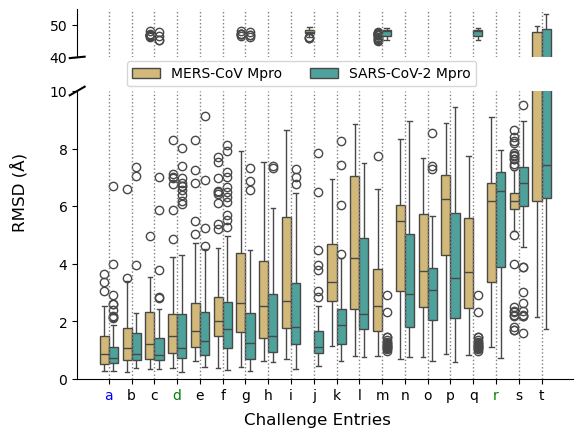

In [74]:
# where is U? 
# workout the baselines and highlight the letters 
f, ax = plt.subplots(ncols=1, nrows=2, gridspec_kw={'hspace':0.2}, height_ratios=[1, 6])
# fig, ax = plt.subplots(1, 2, sharey=True)
sns.boxplot(data=all_rmsd_data_no_u, x="Entry", y="RMSD (A)", hue="Protein", ax=ax[0], palette=["#E1BE6A", "#40B0A6"])
sns.boxplot(data=all_rmsd_data_no_u, x="Entry", y="RMSD (A)", hue="Protein", ax=ax[1], palette=["#E1BE6A", "#40B0A6"])
ax[0].set_ylim((40, 55))
ax[1].set_ylim(0,10)
sns.despine(ax=ax[1])
sns.despine(ax=ax[0], bottom=True)
ax1 = ax[0]
d = .015  # how big to make the diagonal lines in axes coordinates
# arguments to pass to plot, just so we don't keep repeating them
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal

ax2 = ax[1]
kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax[1].legend_.remove()
# sns.boxplot(data=bottom_n, x="Entry", y="RMSD (A)", hue="Protein", ax=ax[0][1], palette=["#E1BE6A", "#40B0A6"])
# sns.boxplot(data=bottom_n, x="Entry", y="RMSD (A)", hue="Protein", ax=ax[1][1], palette=["#E1BE6A", "#40B0A6"])
# ax[0][1].set_ylim((40, 55))
# ax[1][1].set_ylim(0,10)
# sns.despine(ax=ax[1][1])
# # sns.despine(ax=ax[0][1], bottom=True)
# ax1 = ax[0][1]
# d = .015  # how big to make the diagonal lines in axes coordinates
# # arguments to pass to plot, just so we don't keep repeating them
# kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
# ax1.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal

# ax2 = ax[1][1]
# kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
# ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
# ax[1][1].legend_.remove()
# ax[0][1].set_xticks([])
ax[0].set_xticks([])
# ax[0][0].set_xlabel("")
# ax[0][1].set_xlabel("")
# sns.boxplot(data=bottom_n, x="Entry", y="RMSD (A)", hue="Protein", ax=ax[1], legend=None, palette=["#E1BE6A", "#40B0A6"])
# plt.xticks(rotation=90)
# # plt.ylim((0, 10))
ax[0].set_xlabel("")
ax[1].set_xlabel("")
# ax[0].set_ylabel("")
f.supxlabel("Challenge Entries")
f.supylabel("RMSD (Å)")
ax[0].set_ylabel("")
ax[1].set_ylabel("")
ax[1].set_xlabel("")
labels = ax[1].get_xticklabels()
for label in labels:
    if label.get_text() in baseline_clds:
        label.set_color("g")
    elif label.get_text() == "a":
        label.set_color("b")
# labels = ax[1][1].get_xticklabels()
# for label in labels:
#     if label._text in baseline_clds:
#         label.set_color("g")

for i in range(2):
    for xc in range(len(all_rmsd_data_no_u["Entry"].unique())):
        ax[i].axvline(x=xc, color='gray', linestyle=':', linewidth=1)
ax[0].legend(title=None, ncol=2, bbox_to_anchor=(0.1, -0.08), borderaxespad=0., loc="upper left")
# same for the right side 
# plt.ylim((0, 10))  
# plt.savefig("pose_comp.svg", bbox_inches="tight")
# vertical lines to track the outlier

/var/folders/zw/xwwtx7pj5m5_124jv206dyc00000gn/T/ipykernel_75448/3719563159.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


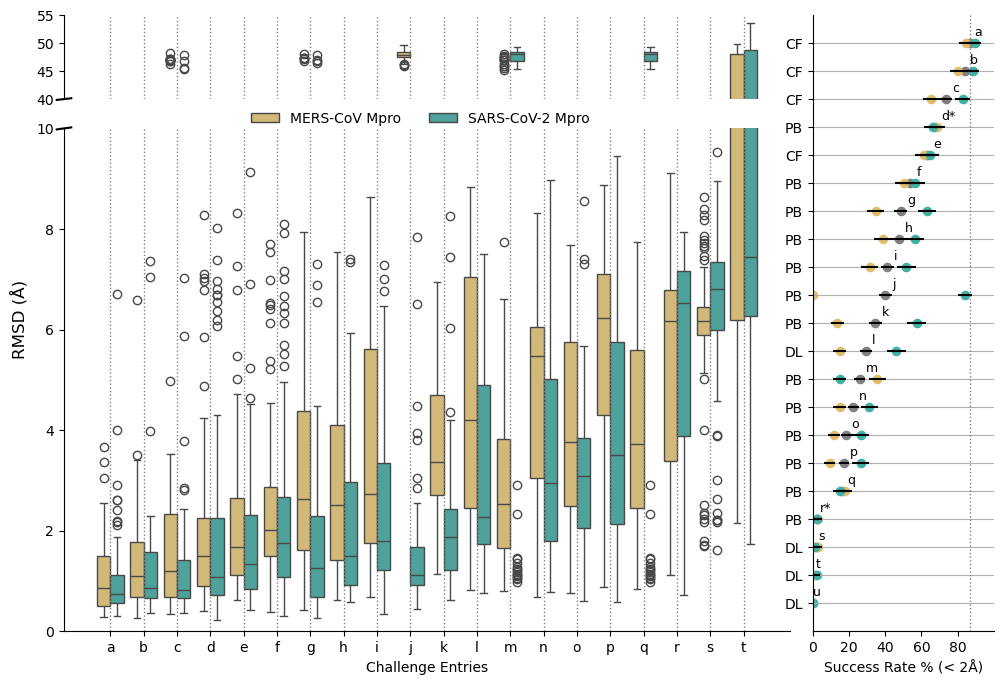

In [75]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Define the grid layout: 2 rows (main plot), 1 column + 1 additional column for the extra plot
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 6], hspace=0.1, wspace=0.05)

# Main plots on the left
ax0 = fig.add_subplot(gs[0, 0])  # Top-left
ax1 = fig.add_subplot(gs[1, 0])  # Bottom-left

# Extra plot on the right
ax_right = fig.add_subplot(gs[:, 1])  # This spans both rows on the right

# Main boxplots
sns.boxplot(data=all_rmsd_data_no_u, x="Entry", y="RMSD (A)", hue="Protein", ax=ax0, palette=["#E1BE6A", "#40B0A6"])
sns.boxplot(data=all_rmsd_data_no_u, x="Entry", y="RMSD (A)", hue="Protein", ax=ax1, palette=["#E1BE6A", "#40B0A6"])

ax0.set_ylim((40, 55))
ax1.set_ylim(0, 10)
sns.despine(ax=ax0, bottom=True)
sns.despine(ax=ax1)

# Break marks
d = .01
kwargs = dict(transform=ax0.transAxes, color='k', clip_on=False)
ax0.plot((-d, +d), (-d, +d), **kwargs)
kwargs.update(transform=ax1.transAxes)
ax1.plot((-d, +d), (1 - d/5, 1 + d/5), **kwargs)

# Clean up
ax0.set_xticks([])
ax1.set_xlabel("Challenge Entries")
ax0.set_xlabel("")
ax0.set_ylabel("")
ax1.set_ylabel("")
# fig.supxlabel("Challenge Entries", y)
fig.supylabel("RMSD (Å)", x=0.08)

# Color tick labels
# labels = ax1.get_xticklabels()
# for label in labels:
#     if label.get_text() in baseline_clds:
#         label.set_color("g")
#     elif label.get_text() == "a":
#         label.set_color("b")

# Add vertical lines per category
for i in [ax0, ax1]:
    for xc in range(len(all_rmsd_data_no_u["Entry"].unique())):
        i.axvline(x=xc, color='gray', linestyle=':', linewidth=1)

# Customize legends
ax1.legend_.remove()
ax0.legend(title=None, ncol=2, bbox_to_anchor=(0.25, -0.08), borderaxespad=0., loc="upper left", frameon=False)

# add the success rate ranking plot to the right
# sars
sars_tick_positions = []
sars_tick_labels = []
metric = "success_rate"
# order by the main score pull out the split data based on this
for i,  (_, entry) in enumerate(main.iterrows()):
    ax_right.scatter(entry[metric + "_raw"], i, s=35, color="grey")
    ax_right.errorbar(entry[metric + "_raw"], i, xerr=entry[metric + "_std"], ls="none", color="k", zorder=5)
    # pull the mers details
    mers_data = mers_main[mers_main["Method"] == entry["Method"]].iloc[0]
    ax_right.scatter(mers_data[metric + "_raw"], i, s=35, color="#E1BE6A")
    ax_right.errorbar(mers_data[metric + "_raw"], i, xerr=mers_data[metric + "_std"], ls="none", color="k", zorder=5)
    # sars
    sars_data = sars_main[sars_main["Method"] == entry["Method"]].iloc[0]
    ax_right.scatter(sars_data[metric + "_raw"], i, s=35, color="#40B0A6")
    ax_right.errorbar(sars_data[metric + "_raw"], i, xerr=sars_data[metric + "_std"], ls="none", color="k", zorder=5)

    label = entry["CLD"]
    if label in ["d", "r"]:
        label += "*"
    ax_right.annotate(label,  xy=(entry[metric + "_raw"] + entry[metric + "_std"], i-0.25), size=9)

    # add in the methodology
    sars_tick_positions.append(i)
    sars_tick_labels.append(entry_categories[entry["Method"]])

ax_right.axvline(main.iloc[0]["success_rate_raw"], color='gray', linestyle=':', linewidth=1)
ax_right.set_yticks(sars_tick_positions, sars_tick_labels)
# ax_right.set_ylim(-1, 24)
ax_right.set_xlim((0, 100))
ax_right.set_xticks(np.arange(0, 100, 20))
ax_right.set_xlabel("Success Rate % (< 2Å)")


ax_right.yaxis.grid(True)

ax_right.invert_yaxis()


# ax_right.legend(handles=[ # make a custom legend
#     patches.Patch(color='tab:blue', label='Top'),
#     patches.Patch(color='tab:orange', label='Equal'),
#     patches.Patch(color='tab:gray', label='Lower'),
#     patches.Patch(color='tab:green', label='Baseline'),

# ], framealpha=1, bbox_to_anchor=(1.4, 1.05))

sns.despine(ax=ax_right)
plt.tight_layout()
# plt.show()
plt.savefig("pose_comp.png", bbox_inches="tight", dpi=300)